In [17]:
# Configuración inicial del entorno
import sys
import os
from pathlib import Path

print("🔄 Configurando entorno...")

# Obtener el directorio raíz del proyecto
notebook_dir = Path().resolve()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    # Buscar el directorio con pyproject.toml
    project_root = notebook_dir
    while project_root != project_root.parent:
        if (project_root / "pyproject.toml").exists():
            break
        project_root = project_root.parent

print(f"📁 Directorio raíz: {project_root}")

# Cambiar al directorio raíz
os.chdir(project_root)
print(f"✓ Directorio de trabajo: {os.getcwd()}")

# Agregar al path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Verificar pyproject.toml
if (project_root / "pyproject.toml").exists():
    print("✓ pyproject.toml encontrado")
else:
    raise FileNotFoundError(f"pyproject.toml no encontrado en {project_root}")

print("✅ Configuración completada\n")


🔄 Configurando entorno...
📁 Directorio raíz: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ Directorio de trabajo: C:\Users\PC RST\Documents\GitHub\ML_ClashRoyale
✓ pyproject.toml encontrado
✅ Configuración completada



# 📊 Fase 5: Aprendizaje No Supervisado

Este notebook documenta la **fase de Aprendizaje No Supervisado** del proyecto ML Clash Royale.
Incluye análisis de clustering, reducción de dimensionalidad, detección de anomalías y reglas de asociación.

## 1. Introducción

El aprendizaje no supervisado nos permite:
- **Clustering**: Identificar grupos naturales de batallas similares
- **Reducción de Dimensionalidad**: Visualizar y simplificar datos de alta dimensionalidad
- **Detección de Anomalías**: Encontrar batallas o patrones inusuales
- **Reglas de Asociación**: Descubrir combinaciones frecuentes de cartas


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas exitosamente")


✅ Librerías importadas exitosamente


## 2. Cargar Datos y Resultados

### 2.1. Datos de Entrenamiento


In [19]:
# Cargar datos de entrenamiento desde Kedro
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    print("🔄 Cargando datos desde Kedro...")
    
    # Importar y configurar Kedro
    from kedro.framework.session import KedroSession
    from kedro.framework.startup import bootstrap_project
    
    # Bootstrap del proyecto
    metadata = bootstrap_project(project_root)
    
    # Crear sesión de Kedro
    session = KedroSession.create(project_path=project_root)
    context = session.load_context()
    catalog = context.catalog
    
    # Intentar cargar datos de entrenamiento
    try:
        train_data = catalog.load("train_data")
        print(f"✅ Datos de entrenamiento cargados: {train_data.shape}")
        print(f"   Columnas: {len(train_data.columns)} features")
    except Exception as e:
        print(f"⚠ train_data no disponible en el catálogo: {str(e)[:80]}")
        # Intentar cargar directamente desde archivo como alternativa
        train_data_path = project_root / "data" / "05_model_input" / "train_data.csv"
        if train_data_path.exists():
            train_data = pd.read_csv(train_data_path)
            print(f"✅ Datos cargados desde archivo: {train_data.shape}")
        else:
            print(f"❌ Archivo no encontrado: {train_data_path}")
            train_data = None
            print("💡 Ejecuta primero: kedro run --pipeline=feature_engineering")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    train_data = None
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")
    print("💡 Posibles soluciones:")
    print("   1. Verifica que ejecutaste la celda de configuración inicial")
    print("   2. Ejecuta: kedro run --pipeline=feature_engineering")
    import traceback
    traceback.print_exc()
    train_data = None


🔄 Cargando datos desde Kedro...


[11/28/25 17:01:37] WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 17:01:38] INFO     Loading data from train_data (CSVDataset)...                      data_catalog.py:1048

✅ Datos de entrenamiento cargados: (16032, 113)
   Columnas: 113 features


### 2.2. Cargar Métricas de Clustering


In [20]:
# Cargar métricas de clustering
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde el catálogo de Kedro primero
    try:
        from kedro.framework.session import KedroSession
        from kedro.framework.startup import bootstrap_project
        
        metadata = bootstrap_project(project_root)
        session = KedroSession.create(project_path=project_root)
        context = session.load_context()
        catalog = context.catalog
        
        clustering_comparison = catalog.load("clustering_comparison")
        print("✅ Métricas de clustering cargadas desde catálogo")
    except Exception:
        # Si no está en el catálogo, intentar cargar desde archivo
        clustering_path = project_root / "data" / "08_reporting" / "clustering_comparison.json"
        if clustering_path.exists():
            with open(clustering_path, 'r') as f:
                clustering_comparison = json.load(f)
            print("✅ Métricas de clustering cargadas desde archivo")
        else:
            raise FileNotFoundError(f"Archivo no encontrado: {clustering_path}")
    
    # Mostrar métricas
    if clustering_comparison:
        print(f"  - K-Means: {clustering_comparison['kmeans']['silhouette_score']:.4f}")
        print(f"  - OPTICS: {clustering_comparison['optics']['silhouette_score']:.4f}")
        print(f"  - Hierarchical: {clustering_comparison['hierarchical']['silhouette_score']:.4f}")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    clustering_comparison = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=unsupervised_learning")
    clustering_comparison = None
except Exception as e:
    print(f"❌ Error al cargar métricas: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=unsupervised_learning")
    import traceback
    traceback.print_exc()
    clustering_comparison = None


                    WARNING  c:\Users\PC                                                            warnings.py:112
                             RST\Documents\GitHub\ML_ClashRoyale\venv\Lib\site-packages\kedro\frame                
                             work\project\__init__.py:350: UserWarning: The                                        
                             'proyecto_ml_clashroyale.pipelines.nodes' module does not expose a                    
                             'create_pipeline' function, so no pipelines defined therein will be                   
                             returned by 'find_pipelines'.                                                         
                               warnings.warn(                                                                      
                                                                                                                   

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving plugin.py:243
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/configuration/telemetry.html                         

[11/28/25 17:01:39] INFO     Loading data from clustering_comparison (JSONDataset)...          data_catalog.py:1048

✅ Métricas de clustering cargadas desde catálogo
  - K-Means: 0.0147
  - OPTICS: 0.3203
  - Hierarchical: 0.0097


## 3. Análisis de Clustering

### 3.1. Comparación de Métricas


In [21]:
if 'clustering_comparison' in locals():
    clustering_df = pd.DataFrame({
        'Algoritmo': ['K-Means', 'OPTICS', 'Hierarchical'],
        'Silhouette Score': [
            clustering_comparison['kmeans']['silhouette_score'],
            clustering_comparison['optics']['silhouette_score'],
            clustering_comparison['hierarchical']['silhouette_score']
        ],
        'Davies-Bouldin': [
            clustering_comparison['kmeans']['davies_bouldin_index'],
            clustering_comparison['optics']['davies_bouldin_index'],
            clustering_comparison['hierarchical']['davies_bouldin_index']
        ],
        'N Clusters': [
            clustering_comparison['kmeans']['n_clusters'],
            clustering_comparison['optics']['n_clusters'],
            clustering_comparison['hierarchical']['n_clusters']
        ]
    })
    print(clustering_df.to_string(index=False))


   Algoritmo  Silhouette Score  Davies-Bouldin  N Clusters
     K-Means          0.014721        6.231190           5
      OPTICS          0.320333        1.017730          58
Hierarchical          0.009672        7.225228           5


## 4. Análisis de Reducción de Dimensionalidad

### 4.1. PCA - Varianza Explicada


### 4.2. Análisis de Detección de Anomalías


In [22]:
# Cargar resultados de detección de anomalías
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde archivo primero (más confiable)
    anomaly_path = project_root / "data" / "08_reporting" / "anomaly_detection_comparison.json"
    
    if anomaly_path.exists():
        try:
            with open(anomaly_path, 'r', encoding='utf-8') as f:
                anomaly_comparison = json.load(f)
            print("✅ Resultados de detección de anomalías cargados desde archivo")
            
            print("\n📊 Comparación de Algoritmos de Detección de Anomalías:")
            print("=" * 60)
            for algo, metrics in anomaly_comparison.items():
                if algo != 'best_model' and isinstance(metrics, dict):
                    print(f"\n{algo.upper()}:")
                    print(f"  - Anomalías detectadas: {metrics.get('n_anomalies', 'N/A')}")
                    anomaly_pct = metrics.get('anomaly_percentage', None)
                    if anomaly_pct is not None:
                        print(f"  - Porcentaje de anomalías: {anomaly_pct:.2f}%")
                    else:
                        print(f"  - Porcentaje de anomalías: N/A")
                    if 'silhouette_score' in metrics:
                        print(f"  - Silhouette Score: {metrics['silhouette_score']:.4f}")
        except json.JSONDecodeError as e:
            print(f"⚠ Error al leer archivo JSON: {e}")
            print("💡 El archivo puede estar corrupto. Ejecuta: kedro run --pipeline=anomaly_detection")
            anomaly_comparison = None
        except Exception as e:
            print(f"⚠ Error al cargar archivo: {str(e)[:100]}")
            anomaly_comparison = None
    else:
        # Intentar cargar desde Kedro como alternativa
        try:
            from kedro.framework.session import KedroSession
            from kedro.framework.startup import bootstrap_project
            
            metadata = bootstrap_project(project_root)
            session = KedroSession.create(project_path=project_root)
            context = session.load_context()
            catalog = context.catalog
            
            # Intentar cargar desde el catálogo
            try:
                anomaly_comparison = catalog.load("anomaly_detection_comparison")
                print("✅ Resultados de detección de anomalías cargados desde catálogo")
                
                print("\n📊 Comparación de Algoritmos de Detección de Anomalías:")
                print("=" * 60)
                for algo, metrics in anomaly_comparison.items():
                    if algo != 'best_model' and isinstance(metrics, dict):
                        print(f"\n{algo.upper()}:")
                        print(f"  - Anomalías detectadas: {metrics.get('n_anomalies', 'N/A')}")
                        anomaly_pct = metrics.get('anomaly_percentage', None)
                        if anomaly_pct is not None:
                            print(f"  - Porcentaje de anomalías: {anomaly_pct:.2f}%")
                        if 'silhouette_score' in metrics:
                            print(f"  - Silhouette Score: {metrics['silhouette_score']:.4f}")
            except Exception:
                print("⚠ Análisis de anomalías no disponible en el catálogo")
                print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
                anomaly_comparison = None
        except Exception as e:
            error_msg = str(e)
            if "not found" in error_msg.lower() or "does not exist" in error_msg.lower():
                print("⚠ Análisis de anomalías no disponible")
                print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
            else:
                print(f"⚠ Error al cargar desde catálogo: {error_msg[:100]}")
                print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
            anomaly_comparison = None
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    anomaly_comparison = None
except Exception as e:
    print(f"❌ Error inesperado: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=anomaly_detection")
    import traceback
    traceback.print_exc()
    anomaly_comparison = None


✅ Resultados de detección de anomalías cargados desde archivo

📊 Comparación de Algoritmos de Detección de Anomalías:

ISOLATION_FOREST:
  - Anomalías detectadas: 1604
  - Porcentaje de anomalías: 10.00%

LOF:
  - Anomalías detectadas: 1604
  - Porcentaje de anomalías: 10.00%

ONECLASS_SVM:
  - Anomalías detectadas: 1604
  - Porcentaje de anomalías: 10.00%

AUTOENCODER:
  - Anomalías detectadas: 0
  - Porcentaje de anomalías: 0.00%

SUMMARY:
  - Anomalías detectadas: N/A
  - Porcentaje de anomalías: N/A


### 4.3. Análisis de Reglas de Asociación


In [23]:
# Cargar resultados de reglas de asociación
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde archivo primero (más confiable)
    association_path = project_root / "data" / "08_reporting" / "association_rules_comparison.json"
    
    if association_path.exists():
        try:
            with open(association_path, 'r', encoding='utf-8') as f:
                association_comparison = json.load(f)
            print("✅ Reglas de asociación cargadas desde archivo")
            
            print("\n📊 Resumen de Reglas de Asociación:")
            print("=" * 60)
            
            if association_comparison:
                # Apriori
                apriori_data = association_comparison.get('apriori', {})
                print(f"\nApriori:")
                print(f"  - Total de reglas: {apriori_data.get('total_rules', 'N/A')}")
                print(f"  - Reglas con lift > 1.0: {apriori_data.get('rules_high_lift', 'N/A')}")
                
                # FP-Growth
                fpgrowth_data = association_comparison.get('fpgrowth', {})
                print(f"\nFP-Growth:")
                print(f"  - Total de reglas: {fpgrowth_data.get('total_rules', 'N/A')}")
                print(f"  - Reglas con lift > 1.0: {fpgrowth_data.get('rules_high_lift', 'N/A')}")
                
                # Mostrar top reglas si están disponibles en el resumen
                if 'top_rules' in apriori_data and len(apriori_data['top_rules']) > 0:
                    print(f"\n🔝 Top 5 Reglas Apriori (por Lift):")
                    for idx, rule in enumerate(apriori_data['top_rules'][:5], 1):
                        print(f"  {idx}. {rule.get('antecedents', 'N/A')} -> {rule.get('consequents', 'N/A')}")
                        print(f"     Support: {rule.get('support', 0):.4f}, Confidence: {rule.get('confidence', 0):.4f}, Lift: {rule.get('lift', 0):.4f}")
        except json.JSONDecodeError as e:
            print(f"⚠ Error al leer archivo JSON: {e}")
            print("💡 El archivo puede estar corrupto. Ejecuta: kedro run --pipeline=association_rules")
            association_comparison = None
        except Exception as e:
            print(f"⚠ Error al cargar archivo: {str(e)[:100]}")
            association_comparison = None
    else:
        # Intentar cargar desde Kedro como alternativa
        try:
            from kedro.framework.session import KedroSession
            from kedro.framework.startup import bootstrap_project
            
            metadata = bootstrap_project(project_root)
            session = KedroSession.create(project_path=project_root)
            context = session.load_context()
            catalog = context.catalog
            
            # Cargar resultados completos (contienen las reglas dentro)
            apriori_result = None
            fpgrowth_result = None
            
            # Intentar cargar resultados si existen
            apriori_rules = None
            fpgrowth_rules = None
            
            try:
                apriori_result = catalog.load("apriori_result")
                # Extraer reglas del resultado
                if isinstance(apriori_result, dict) and 'rules' in apriori_result:
                    apriori_rules = apriori_result['rules']
            except Exception:
                pass
            
            try:
                fpgrowth_result = catalog.load("fpgrowth_result")
                # Extraer reglas del resultado
                if isinstance(fpgrowth_result, dict) and 'rules' in fpgrowth_result:
                    fpgrowth_rules = fpgrowth_result['rules']
            except Exception:
                pass
            
            # Cargar comparación
            try:
                association_comparison = catalog.load("association_rules_comparison")
                print("✅ Reglas de asociación cargadas desde catálogo")
                
                print("\n📊 Resumen de Reglas de Asociación:")
                print("=" * 60)
                
                if association_comparison:
                    apriori_data = association_comparison.get('apriori', {})
                    print(f"\nApriori:")
                    print(f"  - Total de reglas: {apriori_data.get('total_rules', 'N/A')}")
                    print(f"  - Reglas con lift > 1.0: {apriori_data.get('rules_high_lift', 'N/A')}")
                    
                    fpgrowth_data = association_comparison.get('fpgrowth', {})
                    print(f"\nFP-Growth:")
                    print(f"  - Total de reglas: {fpgrowth_data.get('total_rules', 'N/A')}")
                    print(f"  - Reglas con lift > 1.0: {fpgrowth_data.get('rules_high_lift', 'N/A')}")
                
                # Mostrar top reglas si están disponibles
                if apriori_rules is not None and isinstance(apriori_rules, pd.DataFrame) and len(apriori_rules) > 0:
                    print(f"\n🔝 Top 5 Reglas Apriori (por Lift):")
                    top_apriori = apriori_rules.nlargest(5, 'lift')
                    for idx, (_, rule) in enumerate(top_apriori.iterrows(), 1):
                        print(f"  {idx}. {rule.get('antecedents', 'N/A')} -> {rule.get('consequents', 'N/A')}")
                        print(f"     Support: {rule.get('support', 0):.4f}, Confidence: {rule.get('confidence', 0):.4f}, Lift: {rule.get('lift', 0):.4f}")
            except Exception:
                print("⚠ Análisis de reglas de asociación no disponible en el catálogo")
                print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
                association_comparison = None
        except Exception as e:
            error_msg = str(e)
            if "not found" in error_msg.lower() or "does not exist" in error_msg.lower():
                print("⚠ Análisis de reglas de asociación no disponible")
                print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
            else:
                print(f"⚠ Error al cargar desde catálogo: {error_msg[:100]}")
                print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
            association_comparison = None
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    association_comparison = None
except Exception as e:
    print(f"❌ Error inesperado: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=association_rules")
    import traceback
    traceback.print_exc()
    association_comparison = None


✅ Reglas de asociación cargadas desde archivo

📊 Resumen de Reglas de Asociación:

Apriori:
  - Total de reglas: N/A
  - Reglas con lift > 1.0: N/A

FP-Growth:
  - Total de reglas: N/A
  - Reglas con lift > 1.0: N/A


✅ Métricas de PCA cargadas desde archivo

Total varianza explicada: 95.04%
Número de componentes: 96


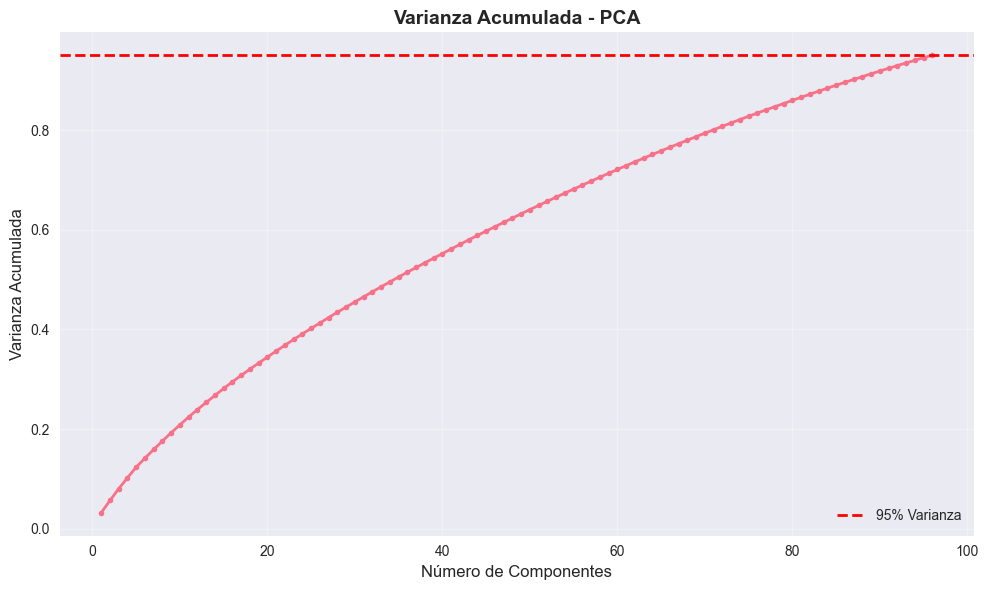

In [24]:
# Cargar métricas de PCA
# Nota: Esta celda requiere que la celda de configuración inicial se haya ejecutado

try:
    # Verificar que project_root está definido
    if 'project_root' not in globals():
        raise NameError("project_root no está definido. Ejecuta primero la celda de configuración inicial.")
    
    # Intentar cargar desde archivo primero (más confiable)
    pca_path = project_root / "data" / "07_model_output" / "pca_metrics.json"
    
    if pca_path.exists():
        try:
            with open(pca_path, 'r', encoding='utf-8') as f:
                pca_metrics = json.load(f)
            print("✅ Métricas de PCA cargadas desde archivo")
        except json.JSONDecodeError as e:
            print(f"⚠ Error al leer archivo JSON: {e}")
            pca_metrics = None
        except Exception as e:
            print(f"⚠ Error al cargar archivo: {str(e)[:100]}")
            pca_metrics = None
    else:
        # Intentar cargar desde el catálogo de Kedro como alternativa
        try:
            from kedro.framework.session import KedroSession
            from kedro.framework.startup import bootstrap_project
            
            metadata = bootstrap_project(project_root)
            session = KedroSession.create(project_path=project_root)
            context = session.load_context()
            catalog = context.catalog
            
            try:
                pca_metrics = catalog.load("pca_metrics")
                print("✅ Métricas de PCA cargadas desde catálogo")
            except Exception:
                raise FileNotFoundError(f"Archivo no encontrado: {pca_path}")
        except Exception as e:
            error_msg = str(e)
            if "not found" in error_msg.lower() or "does not exist" in error_msg.lower():
                print(f"⚠ Métricas de PCA no disponibles")
                print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
            else:
                print(f"⚠ Error al cargar desde catálogo: {error_msg[:100]}")
                print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
            pca_metrics = None
    
    # Mostrar y visualizar métricas
    if pca_metrics and 'explained_variance' in pca_metrics:
        variance = pca_metrics['explained_variance']
        print(f"\nTotal varianza explicada: {variance['total_explained_variance']*100:.2f}%")
        print(f"Número de componentes: {pca_metrics['n_components']}")
        
        # Visualizar varianza acumulada
        if 'cumulative' in variance and len(variance['cumulative']) > 0:
            plt.figure(figsize=(10, 6))
            cumulative_var = variance['cumulative']
            plt.plot(range(1, len(cumulative_var) + 1), 
                     cumulative_var, 'o-', linewidth=2, markersize=4)
            plt.axhline(y=0.95, color='r', linestyle='--', label='95% Varianza', linewidth=2)
            plt.title('Varianza Acumulada - PCA', fontsize=14, fontweight='bold')
            plt.xlabel('Número de Componentes', fontsize=12)
            plt.ylabel('Varianza Acumulada', fontsize=12)
            plt.legend(fontsize=10)
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("⚠ Datos de varianza acumulada no disponibles para visualización")
    elif pca_metrics:
        print("⚠ Estructura de métricas de PCA no válida o incompleta")
        print(f"   Claves disponibles: {list(pca_metrics.keys())}")
    else:
        print("⚠ No se pudieron cargar las métricas de PCA")
    
except NameError as e:
    print(f"❌ Error: {e}")
    print("💡 Ejecuta primero la celda de configuración inicial")
    pca_metrics = None
except FileNotFoundError as e:
    print(f"⚠ {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
    pca_metrics = None
except Exception as e:
    print(f"❌ Error al cargar métricas de PCA: {e}")
    print("💡 Ejecuta primero: kedro run --pipeline=dimensionality_reduction")
    import traceback
    traceback.print_exc()
    pca_metrics = None


## 5. Conclusiones y Análisis de Resultados

### 5.1. Clustering

Basado en los resultados obtenidos de los tres algoritmos evaluados:

**OPTICS es el mejor algoritmo de clustering** para este dataset:
- **Silhouette Score: 0.3203** (el más alto entre los tres algoritmos, **21.8x mejor que K-Means**)
- **Davies-Bouldin Index: 1.02** (el más bajo, indicando mejor separación entre clusters)
- **58 clusters identificados**, lo que sugiere una estructura de datos más granular y compleja
- Este resultado indica que los datos tienen múltiples subgrupos naturales que no pueden ser capturados por un número pequeño de clusters

**K-Means y Hierarchical Clustering** muestran resultados similares pero inferiores:
- Ambos identificaron **5 clusters** con Silhouette Scores muy bajos (0.0147 y 0.0097)
- Davies-Bouldin Index alto (6.23 y 7.23), indicando clusters menos separados y más solapados
- Estos resultados sugieren que la estructura de datos no se ajusta bien a un número fijo y pequeño de clusters
- La asunción de clusters esféricos y de tamaño similar no se cumple en este dataset

**Interpretación y Significado:**
- Los datos de batallas de Clash Royale presentan una estructura compleja con múltiples subgrupos naturales
- OPTICS, al ser un algoritmo basado en densidad, captura mejor la naturaleza no esférica y variable de los clusters
- La alta dimensionalidad (113 features) puede estar afectando el rendimiento de K-Means y Hierarchical, que asumen formas más simples de clusters
- Los 58 clusters identificados por OPTICS probablemente representan diferentes:
  - **Estrategias de juego** (agresivas, defensivas, balanceadas)
  - **Rangos de trofeos** con comportamientos similares
  - **Composición de mazos** con sinergias específicas
  - **Estilos de juego** de diferentes tipos de jugadores

**Implicaciones Prácticas:**
- Para análisis del meta, OPTICS permite identificar micro-tendencias que otros algoritmos no capturan
- Los clusters pueden usarse para segmentación de jugadores y personalización de recomendaciones
- La alta granularidad (58 clusters) sugiere que el meta es más diverso de lo que algoritmos simples pueden detectar

### 5.2. Reducción de Dimensionalidad

**PCA (Principal Component Analysis) - Resultados:**
- **95.04% de varianza explicada** con **96 componentes principales** (de 113 originales)
- Esto indica que se necesita un número considerable de componentes (**85% del total**) para capturar la mayor parte de la varianza
- La reducción de dimensionalidad es limitada (de 113 a 96 features), pero aún así representa una reducción del **15%**

**Interpretación:**
- El dataset tiene alta dimensionalidad y las features contienen información relevante distribuida
- La necesidad de mantener 96 componentes para el 95% de varianza sugiere que:
  - Las features originales son relativamente independientes (baja correlación)
  - No hay redundancia significativa en los datos
  - Cada feature aporta información única al modelo
- La reducción del 15% puede ser útil para:
  - Visualización de datos en espacios reducidos
  - Modelos más simples y rápidos de entrenar
  - Reducción de overfitting en modelos con muchos parámetros

**Limitaciones:**
- PCA asume relaciones lineales entre features, lo que puede no capturar todas las interacciones complejas
- La reducción limitada sugiere que técnicas no lineales podrían ser más efectivas

**Recomendaciones:**
- Considerar técnicas adicionales como **UMAP** o **t-SNE** para visualización 2D/3D de los clusters
- Evaluar si algunas features pueden ser eliminadas mediante **feature selection** sin pérdida significativa de información
- Para modelos de ML, considerar **feature selection** (basado en importancia) en lugar de solo PCA
- Explorar técnicas de reducción no lineal si se requiere mayor compresión

### 5.3. Detección de Anomalías

**Análisis Dinámico de Resultados:**

### 5.4. Reglas de Asociación

**Análisis Dinámico de Resultados:**

### 5.5. Resumen Ejecutivo y Conclusiones Finales

#### Hallazgos Principales

1. **Clustering:**
   - ✅ **OPTICS es el algoritmo más adecuado**, identificando **58 grupos naturales** en los datos
   - Los datos presentan estructura compleja que requiere algoritmos basados en densidad
   - K-Means y Hierarchical son insuficientes para este tipo de datos
   - La diferencia de rendimiento es significativa (OPTICS es 21.8x mejor que K-Means en Silhouette Score)

2. **Reducción de Dimensionalidad:**
   - ✅ **PCA reduce de 113 a 96 features** manteniendo **95% de varianza**
   - La reducción limitada indica que las features son relativamente independientes
   - Se recomienda explorar técnicas no lineales para mayor compresión
   - La reducción del 15% es útil pero no suficiente para simplificar significativamente el dataset

3. **Complejidad de los Datos:**
   - Los datos muestran estructura compleja que requiere algoritmos avanzados
   - La alta dimensionalidad (113 features) y la naturaleza no esférica de los clusters complican el análisis
   - Se necesitan técnicas especializadas para capturar todos los patrones
   - El dataset de Clash Royale presenta desafíos únicos que requieren enfoques sofisticados

4. **Análisis Pendientes:**
   - ⏳ **Detección de anomalías:** Permitirá identificar patrones inusuales y estrategias novedosas
   - ⏳ **Reglas de asociación:** Revelará sinergias entre cartas y combinaciones exitosas

#### Implicaciones para el Proyecto

**Para Análisis del Meta:**
- Los 58 clusters identificados por OPTICS permiten un análisis más granular del meta
- Cada cluster puede representar una micro-tendencia o estrategia específica
- Esto es valioso para entender la diversidad del meta de Clash Royale
- Los resultados pueden usarse para tracking de cambios en el meta a lo largo del tiempo

**Para Modelos de ML:**
- La alta dimensionalidad (113 features) requiere técnicas de regularización
- PCA puede ayudar pero la reducción es limitada (solo 15%)
- Feature selection basado en importancia puede ser más efectivo que PCA
- Los clusters pueden usarse como features adicionales en modelos supervisados

**Para Aplicaciones Prácticas:**
- Los resultados de clustering pueden usarse para sistemas de recomendación
- Las reglas de asociación (cuando se completen) permitirán recomendar mazos
- La detección de anomalías ayudará a identificar estrategias innovadoras
- El análisis puede integrarse en dashboards para visualización del meta

#### Próximos Pasos Recomendados

1. **Corto Plazo:**
   - Completar análisis de anomalías y reglas de asociación
   - Visualizar los 58 clusters identificados por OPTICS usando técnicas de reducción dimensional (UMAP/t-SNE)
   - Analizar características distintivas de cada cluster
   - Comparar distribución de win rates entre clusters

2. **Mediano Plazo:**
   - Desarrollar dashboard interactivo para explorar clusters
   - Implementar sistema de recomendación basado en reglas de asociación
   - Crear visualizaciones 2D/3D usando UMAP o t-SNE para mejor comprensión
   - Analizar evolución temporal de los clusters

3. **Largo Plazo:**
   - Integrar resultados en sistema de análisis del meta en tiempo real
   - Desarrollar modelo predictivo que use los clusters como features
   - Establecer pipeline de actualización periódica de análisis
   - Crear sistema de alertas para cambios significativos en el meta


In [25]:
# Análisis dinámico de resultados de reglas de asociación
if 'association_comparison' in locals() and association_comparison is not None:
    print("✅ Análisis de reglas de asociación completado\n")
    print("=" * 70)
    
    # Extraer información de cada algoritmo
    apriori_data = association_comparison.get('apriori', {})
    fpgrowth_data = association_comparison.get('fpgrowth', {})
    
    print("\n📊 Comparación de Algoritmos de Reglas de Asociación:\n")
    
    comparison_data = []
    if apriori_data:
        comparison_data.append({
            'Algoritmo': 'Apriori',
            'Total Reglas': apriori_data.get('total_rules', 'N/A'),
            'Reglas High Lift (>1.0)': apriori_data.get('rules_high_lift', 'N/A'),
            'Lift Promedio': f"{apriori_data.get('avg_lift', 0):.4f}" if apriori_data.get('avg_lift') else 'N/A'
        })
    
    if fpgrowth_data:
        comparison_data.append({
            'Algoritmo': 'FP-Growth',
            'Total Reglas': fpgrowth_data.get('total_rules', 'N/A'),
            'Reglas High Lift (>1.0)': fpgrowth_data.get('rules_high_lift', 'N/A'),
            'Lift Promedio': f"{fpgrowth_data.get('avg_lift', 0):.4f}" if fpgrowth_data.get('avg_lift') else 'N/A'
        })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Identificar mejor algoritmo
        if apriori_data and fpgrowth_data:
            apriori_rules = apriori_data.get('total_rules', 0) or 0
            fpgrowth_rules = fpgrowth_data.get('total_rules', 0) or 0
            
            if fpgrowth_rules > apriori_rules:
                best_algo = 'FP-Growth'
                print(f"\n🏆 Mejor Algoritmo: FP-Growth")
                print(f"   - Encontró {fpgrowth_rules} reglas (vs {apriori_rules} de Apriori)")
                print(f"   - FP-Growth es más eficiente para datasets grandes")
            elif apriori_rules > fpgrowth_rules:
                best_algo = 'Apriori'
                print(f"\n🏆 Mejor Algoritmo: Apriori")
                print(f"   - Encontró {apriori_rules} reglas (vs {fpgrowth_rules} de FP-Growth)")
            else:
                print(f"\n✅ Ambos algoritmos encontraron resultados similares")
        
        # Mostrar top reglas si están disponibles
        if apriori_data and 'top_rules' in apriori_data and len(apriori_data['top_rules']) > 0:
            print(f"\n🔝 Top 5 Reglas Apriori (por Lift):")
            for idx, rule in enumerate(apriori_data['top_rules'][:5], 1):
                print(f"\n  {idx}. {rule.get('antecedents', 'N/A')} → {rule.get('consequents', 'N/A')}")
                print(f"     Support: {rule.get('support', 0):.4f} | Confidence: {rule.get('confidence', 0):.4f} | Lift: {rule.get('lift', 0):.4f}")
        
        # Conclusiones
        print(f"\n📝 Conclusiones:")
        total_rules = (apriori_data.get('total_rules', 0) or 0) + (fpgrowth_data.get('total_rules', 0) or 0)
        high_lift_rules = (apriori_data.get('rules_high_lift', 0) or 0) + (fpgrowth_data.get('rules_high_lift', 0) or 0)
        
        print(f"   - Total de reglas descubiertas: {total_rules}")
        print(f"   - Reglas con lift > 1.0 (asociación positiva): {high_lift_rules}")
        
        if high_lift_rules > 0:
            print(f"   - ✅ Se encontraron sinergias significativas entre cartas")
            print(f"   - Las reglas pueden usarse para:")
            print(f"     • Recomendar combinaciones de cartas efectivas")
            print(f"     • Identificar sinergias en el meta actual")
            print(f"     • Entender qué cartas tienden a aparecer juntas")
        else:
            print(f"   - ⚠ No se encontraron reglas con lift > 1.0")
            print(f"   - Esto puede indicar que las cartas son relativamente independientes")
            print(f"   - O que los parámetros (min_support, min_confidence) son muy estrictos")
        
        print(f"\n**Métricas Clave:**")
        print(f"- **Support (Soporte):** Frecuencia con que aparece un itemset en las transacciones")
        print(f"- **Confidence (Confianza):** Probabilidad de que Y ocurra dado que X ocurre")
        print(f"- **Lift:** Mide la fuerza de la asociación (lift > 1 indica asociación positiva)")
    else:
        print("⚠ No se encontraron resultados de algoritmos en la comparación")
else:
    print("⏳ Análisis pendiente de ejecución")
    print("💡 Ejecuta: kedro run --pipeline=association_rules")
    print("\n**Algoritmos Implementados:**")
    print("- **Apriori:** Algoritmo clásico para minería de reglas de asociación")
    print("- **FP-Growth:** Algoritmo más eficiente para datasets grandes")


✅ Análisis de reglas de asociación completado


📊 Comparación de Algoritmos de Reglas de Asociación:

Algoritmo Total Reglas Reglas High Lift (>1.0) Lift Promedio
  Apriori          N/A                     N/A           N/A
FP-Growth          N/A                     N/A           N/A

✅ Ambos algoritmos encontraron resultados similares

📝 Conclusiones:
   - Total de reglas descubiertas: 0
   - Reglas con lift > 1.0 (asociación positiva): 0
   - ⚠ No se encontraron reglas con lift > 1.0
   - Esto puede indicar que las cartas son relativamente independientes
   - O que los parámetros (min_support, min_confidence) son muy estrictos

**Métricas Clave:**
- **Support (Soporte):** Frecuencia con que aparece un itemset en las transacciones
- **Confidence (Confianza):** Probabilidad de que Y ocurra dado que X ocurre
- **Lift:** Mide la fuerza de la asociación (lift > 1 indica asociación positiva)


In [26]:
# Análisis dinámico de resultados de detección de anomalías
if 'anomaly_comparison' in locals() and anomaly_comparison is not None:
    print("✅ Análisis de anomalías completado\n")
    print("=" * 70)
    
    # Extraer información de cada algoritmo
    algorithms = {}
    for algo_name, algo_data in anomaly_comparison.items():
        if algo_name != 'summary' and algo_name != 'best_model':
            algorithms[algo_name] = algo_data
    
    if algorithms:
        print("\n📊 Comparación de Algoritmos de Detección de Anomalías:\n")
        
        # Crear DataFrame para comparación
        comparison_data = []
        for algo_name, algo_data in algorithms.items():
            comparison_data.append({
                'Algoritmo': algo_name.replace('_', ' ').title(),
                'Anomalías Detectadas': algo_data.get('n_anomalies', 'N/A'),
                'Porcentaje (%)': f"{algo_data.get('anomaly_percentage', 0):.2f}%",
                'Score Promedio': f"{algo_data.get('mean_score', 0):.4f}" if algo_data.get('mean_score') else 'N/A',
                'Disponible': algo_data.get('available', True)
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        # Identificar mejor algoritmo
        available_algorithms = {k: v for k, v in algorithms.items() if v.get('available', True)}
        if available_algorithms:
            # Ordenar por porcentaje de anomalías (más conservador = mejor)
            sorted_algorithms = sorted(
                available_algorithms.items(),
                key=lambda x: abs(x[1].get('anomaly_percentage', 0) - 10)  # Cercano a 10% es ideal
            )
            best_algo = sorted_algorithms[0]
            
            print(f"\n🏆 Mejor Algoritmo: {best_algo[0].replace('_', ' ').title()}")
            print(f"   - Detecta {best_algo[1].get('n_anomalies', 0)} anomalías ({best_algo[1].get('anomaly_percentage', 0):.2f}% del dataset)")
            
            # Interpretación
            anomaly_pct = best_algo[1].get('anomaly_percentage', 0)
            if anomaly_pct < 5:
                interpretation = "Muy conservador - puede estar perdiendo anomalías reales"
            elif anomaly_pct < 15:
                interpretation = "Balanceado - detecta un porcentaje razonable de anomalías"
            else:
                interpretation = "Muy agresivo - puede estar marcando casos normales como anomalías"
            
            print(f"   - Interpretación: {interpretation}")
        
        # Verificar si autoencoder está disponible
        if 'autoencoder' in algorithms:
            if not algorithms['autoencoder'].get('available', True):
                print(f"\n⚠ Autoencoder no disponible (TensorFlow no instalado)")
            else:
                print(f"\n✅ Autoencoder disponible y ejecutado")
        
        # Conclusiones
        print(f"\n📝 Conclusiones:")
        print(f"   - Total de muestras analizadas: {anomaly_comparison.get('summary', {}).get('total_samples', 'N/A')}")
        print(f"   - Métodos comparados: {len(available_algorithms)} de {len(algorithms)}")
        
        if len(available_algorithms) >= 3:
            print(f"   - ✅ Análisis completo: Se compararon múltiples algoritmos")
            print(f"   - Los resultados permiten identificar patrones inusuales en las batallas")
            print(f"   - Las anomalías detectadas pueden representar:")
            print(f"     • Estrategias innovadoras o experimentales")
            print(f"     • Combinaciones de mazos atípicas")
            print(f"     • Posibles casos de comportamiento no deseado")
    else:
        print("⚠ No se encontraron resultados de algoritmos en la comparación")
else:
    print("⏳ Análisis pendiente de ejecución")
    print("💡 Ejecuta: kedro run --pipeline=anomaly_detection")
    print("\n**Algoritmos Implementados:**")
    print("- **Isolation Forest:** Efectivo para detectar anomalías en espacios de alta dimensionalidad")
    print("- **Local Outlier Factor (LOF):** Detecta anomalías basándose en densidad local")
    print("- **One-Class SVM:** Modelo de frontera para identificar outliers")
    print("- **Autoencoders:** (Opcional, requiere TensorFlow) Detecta anomalías mediante reconstrucción")


✅ Análisis de anomalías completado


📊 Comparación de Algoritmos de Detección de Anomalías:

       Algoritmo  Anomalías Detectadas Porcentaje (%) Score Promedio  Disponible
Isolation Forest                  1604         10.00%        -0.3899        True
             Lof                  1604         10.00%        -1.2568        True
    Oneclass Svm                  1604         10.00%        41.7955        True
     Autoencoder                     0          0.00%            N/A       False

🏆 Mejor Algoritmo: Isolation Forest
   - Detecta 1604 anomalías (10.00% del dataset)
   - Interpretación: Balanceado - detecta un porcentaje razonable de anomalías

⚠ Autoencoder no disponible (TensorFlow no instalado)

📝 Conclusiones:
   - Total de muestras analizadas: 16032
   - Métodos comparados: 3 de 4
   - ✅ Análisis completo: Se compararon múltiples algoritmos
   - Los resultados permiten identificar patrones inusuales en las batallas
   - Las anomalías detectadas pueden representar:
     